In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)


# Zadanie 1

In [2]:
rozklady = {
    'Beta (a=2, b=2)': stats.beta(a=2, b=2),
    'Dwumianowy (n=10, p=0.5)': stats.binom(n=10, p=0.5),
    'Cauchy\'ego (loc=0, scale=1)': stats.cauchy(loc=0, scale=1),
    'Chi-kwadrat (df=5)': stats.chi2(df=5),
    'Wykładniczy (scale=1)': stats.expon(scale=1),
    'F-Snedecora (dfn=5, dfd=7)': stats.f(dfn=5, dfd=7),
    'Gamma (a=2)': stats.gamma(a=2),
    'Geometryczny (p=0.3)': stats.geom(p=0.3),
    'Hipergeometryczny (M=20, n=7, N=12)': stats.hypergeom(M=20, n=7, N=12),
    'Log-normalny (s=1)': stats.lognorm(s=1),
    'Logistyczny (loc=0, scale=1)': stats.logistic(loc=0, scale=1),
    'Ujemny dwumianowy (n=5, p=0.5)': stats.nbinom(n=5, p=0.5),
    'Normalny N(0,1)': stats.norm(loc=0, scale=1),
    'Poissona (mu=3)': stats.poisson(mu=3),
    't-Studenta (df=3)': stats.t(df=3),
    'Jednostajny U(0,1)': stats.uniform(loc=0, scale=1),
    'Weibulla (c=1.5)': stats.weibull_min(c=1.5)
}

In [3]:
lista_wynikow = []
rozmiar_probki = 20000

for nazwa, dist in rozklady.items():
    probka = dist.rvs(size=rozmiar_probki)
    mean_teo, var_teo, skew_teo, kurt_teo = dist.stats(moments='mvsk')

    mean_emp = np.mean(probka)
    var_emp = np.var(probka, ddof=1)
    skew_emp = stats.skew(probka, nan_policy='omit')
    kurt_emp = stats.kurtosis(probka, nan_policy='omit')

    lista_wynikow.append({
        'Nazwa rozkładu': nazwa,
        'Średnia (Teoria)': float(mean_teo),
        'Średnia (Próbka)': mean_emp,
        'Wariancja (Teoria)': float(var_teo),
        'Wariancja (Próbka)': var_emp,
        'Skośność (Teoria)': float(skew_teo),
        'Skośność (Próbka)': skew_emp,
        'Kurtoza (Teoria)': float(kurt_teo),
        'Kurtoza (Próbka)': kurt_emp
    })

df = pd.DataFrame(lista_wynikow)

Przeprowadzony eksperyment potwierdza, że dla większości klasycznych rozkładów wartości empiryczne z próbki niemal idealnie pokrywają się z teoretycznymi. Dla rozkładów asymetrycznych, takich jak log-normalny, wyższe parametry zbiegają do teorii wolniej.

# Zadanie 2

   Zysk netto (X)  Prawdopodobieństwo P(X)  Dystrybuanta F(x)
0              -2                   0.4167             0.4167
1              -1                   0.1944             0.6111
2               0                   0.1944             0.8056
3               3                   0.1944             1.0000

Wartość oczekiwana E(X): -0.4444 zł
Wariancja Var(X): 3.4136
Gracz powinien unikać tej gry, ponieważ średnio traci pieniądze.
SYMULACJA BANKRUCTWA (10 000 prób)
Średnio gracz traci cały budżet (1000 zł) po: 2249 rzutach.


Text(0, 0.5, 'Częstotliwość')

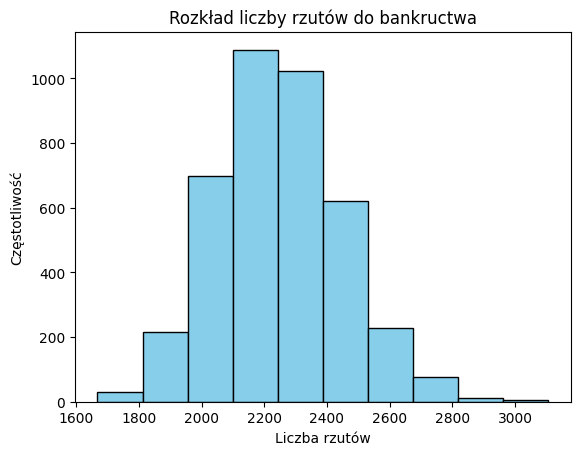

In [4]:
X = np.array([-2, -1, 0, 3])
P_X = np.array([(2 / 6) + (1 / 6) * (3 / 6),
                (1 / 6) + (1 / 6) * (1 / 6),
                (1 / 6) + (1 / 6) * (1 / 6),
                (1 / 6) + (1 / 6) * (1 / 6)])

df = pd.DataFrame({
    'Zysk netto (X)': X,
    'Prawdopodobieństwo P(X)': P_X,
    'Dystrybuanta F(x)': np.cumsum(P_X)
})

wartosc_oczekiwana = np.sum(X * P_X)
wariancja = np.sum((X - wartosc_oczekiwana) ** 2 * P_X)

print(df.round(4))
print(f'\nWartość oczekiwana E(X): {wartosc_oczekiwana:.4f} zł')
print(f'Wariancja Var(X): {wariancja:.4f}')

if wartosc_oczekiwana < 0:
    print('Gracz powinien unikać tej gry, ponieważ średnio traci pieniądze.')
else:
    print('Gracz może rozważyć udział w tej grze, ponieważ średnio zyskuje pieniądze.')
np.random.seed(42)
liczba_symulacji = 4000
pieniadze_na_start = 1000
koszt_gry = 2

runda_bankructwa = []

for _ in range(liczba_symulacji):
    budzet = pieniadze_na_start
    rzuty = 0

    while budzet >= koszt_gry:
        zysk_z_rzutu = np.random.choice(X, p=P_X)
        budzet += zysk_z_rzutu
        rzuty += 1

    runda_bankructwa.append(rzuty)

srednia_liczba_rzutow = np.mean(runda_bankructwa)

print('SYMULACJA BANKRUCTWA (10 000 prób)')
print(f'Średnio gracz traci cały budżet (1000 zł) po: {srednia_liczba_rzutow:.0f} rzutach.')

plt.hist(runda_bankructwa, edgecolor='black', color = 'skyblue')
plt.title('Rozkład liczby rzutów do bankructwa')
plt.xlabel('Liczba rzutów')
plt.ylabel('Częstotliwość')



# Zadanie 3

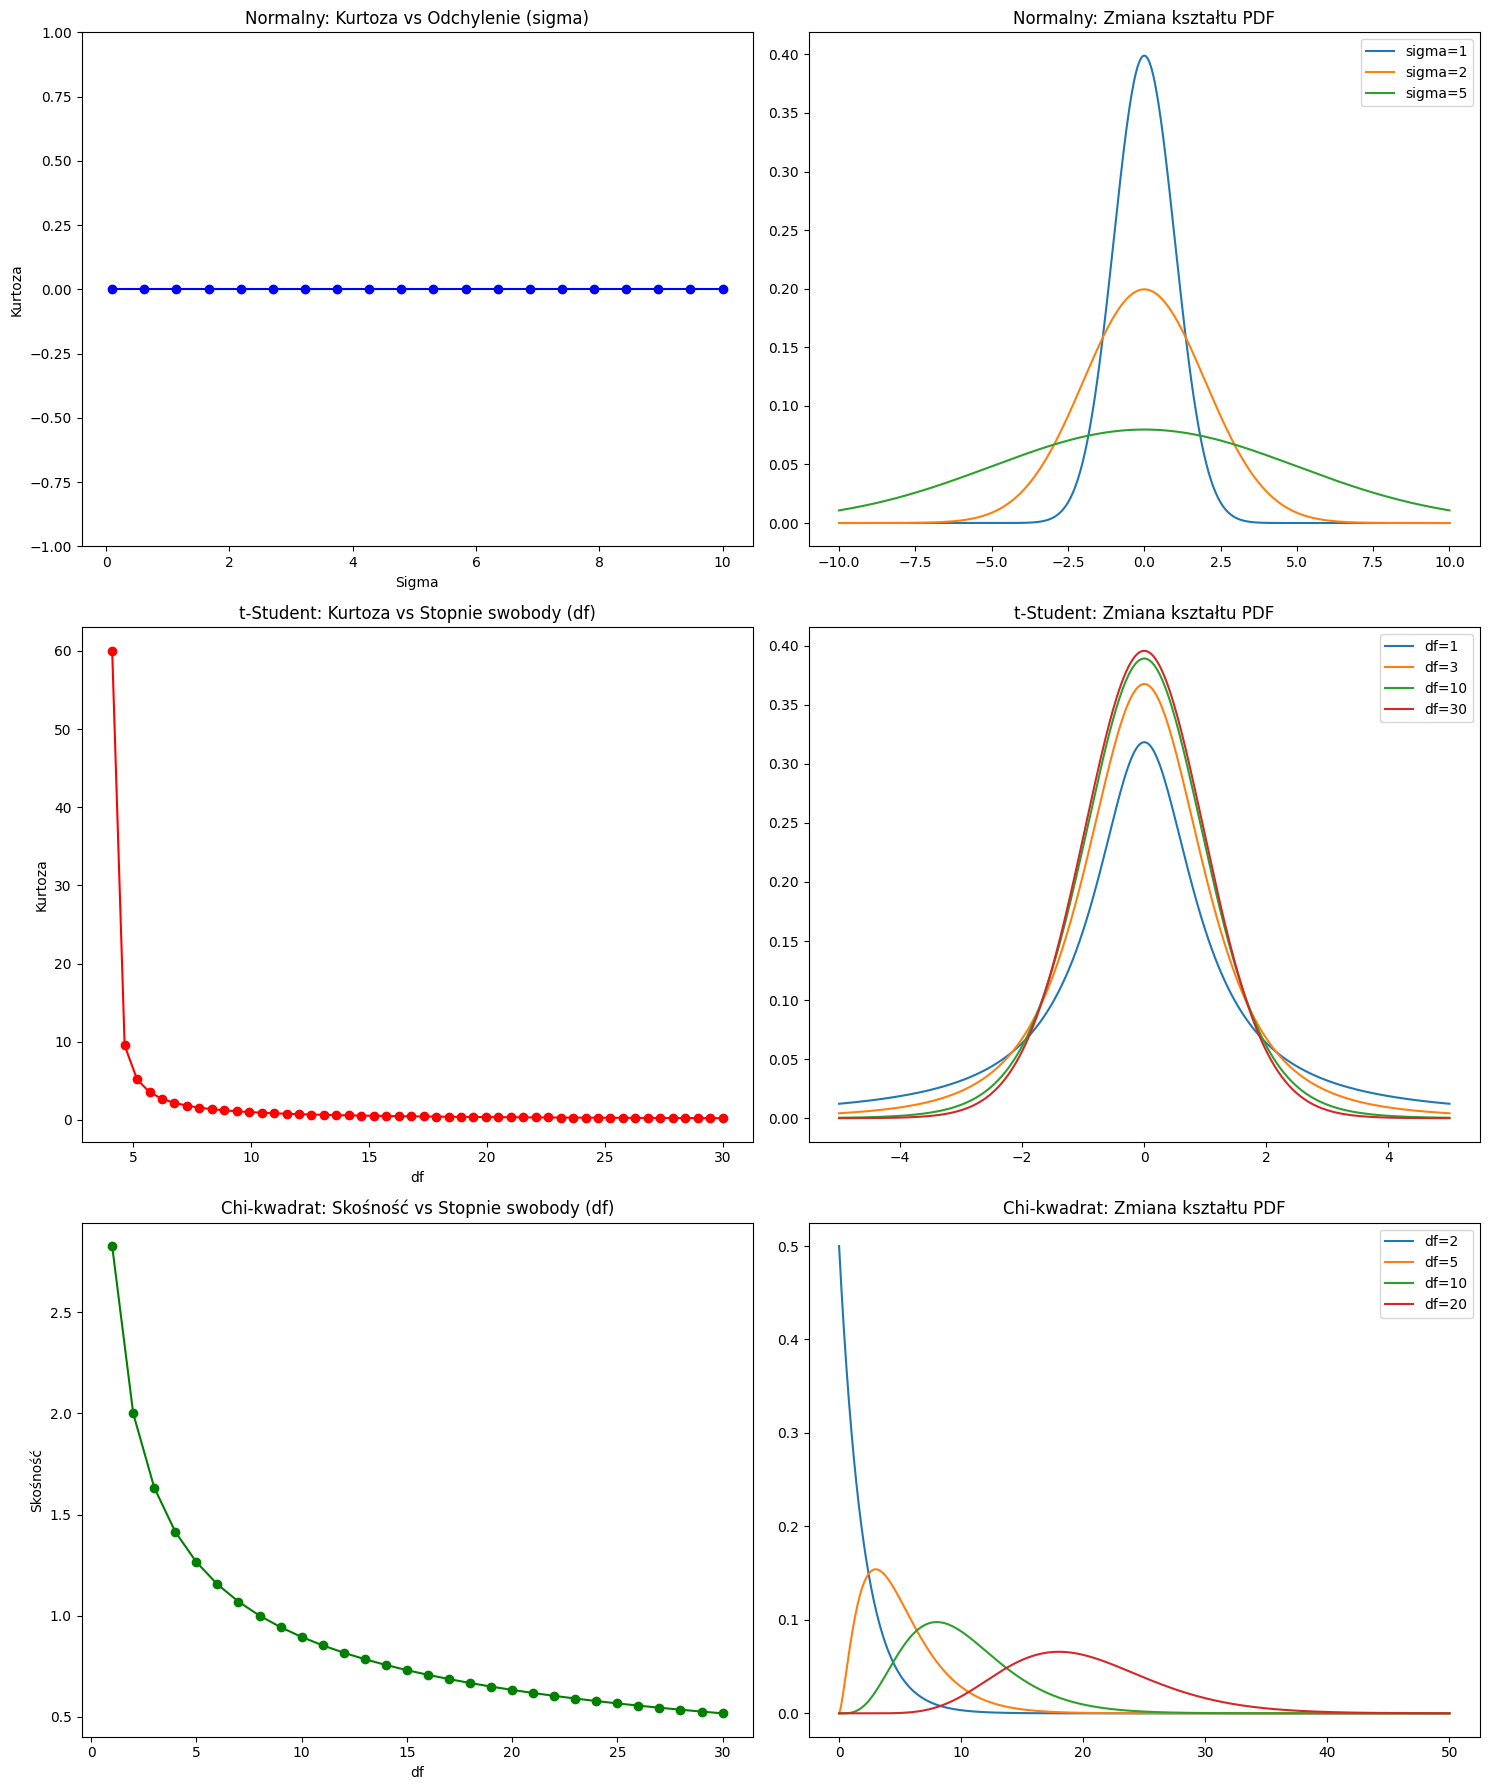

Kurtoza rozkładu normalnego (wybrane sigmy):
      Sigma  Kurtoza
0  0.100000      0.0
1  2.184211      0.0
2  4.268421      0.0
3  6.352632      0.0
4  8.436842      0.0

Kurtoza rozkładu t-Studenta (wybrane df):
          df    Kurtoza
0   4.100000  60.000000
1   9.385714   1.114058
2  14.671429   0.562249
3  19.957143   0.376007
4  25.242857   0.282448

Skośność rozkładu Chi-kwadrat (wybrane df):
   df  Skośność
0   1  2.828427
1   6  1.154701
2  11  0.852803
3  16  0.707107
4  21  0.617213
5  26  0.554700


In [5]:
# ROZKŁAD NORMALNY
sigmas = np.linspace(0.1, 10, 20)
norm_kurtosis_theo = [stats.norm.stats(loc=0, scale=s, moments='k') for s in sigmas]

#ROZKŁAD t-STUDENTA
dfs_t = np.linspace(4.1, 30, 50)
t_kurtosis_theo = [stats.t.stats(df=d, moments='k') for d in dfs_t]

#ROZKŁAD CHI-KWADRAT
dfs_chi = np.arange(1, 31)
chi_skew_theo = [stats.chi2.stats(df=d, moments='s') for d in dfs_chi]


fig, axes = plt.subplots(3, 2, figsize=(15, 18))

axes[0, 0].plot(sigmas, norm_kurtosis_theo, 'o-', color='blue')
axes[0, 0].set_title('Normalny: Kurtoza vs Odchylenie (sigma)')
axes[0, 0].set_xlabel('Sigma')
axes[0, 0].set_ylabel('Kurtoza')
axes[0, 0].set_ylim(-1, 1)

x_norm = np.linspace(-10, 10, 500)
for s in [1, 2, 5]:
    axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, 0, s), label=f'sigma={s}')
axes[0, 1].set_title('Normalny: Zmiana kształtu PDF')
axes[0, 1].legend()

axes[1, 0].plot(dfs_t, t_kurtosis_theo, 'o-', color='red')
axes[1, 0].set_title('t-Student: Kurtoza vs Stopnie swobody (df)')
axes[1, 0].set_xlabel('df')
axes[1, 0].set_ylabel('Kurtoza')

x_t = np.linspace(-5, 5, 500)
for d in [1, 3, 10, 30]:
    axes[1, 1].plot(x_t, stats.t.pdf(x_t, df=d), label=f'df={d}')
axes[1, 1].set_title('t-Student: Zmiana kształtu PDF')
axes[1, 1].legend()

axes[2, 0].plot(dfs_chi, chi_skew_theo, 'o-', color='green')
axes[2, 0].set_title('Chi-kwadrat: Skośność vs Stopnie swobody (df)')
axes[2, 0].set_xlabel('df')
axes[2, 0].set_ylabel('Skośność')

x_chi = np.linspace(0, 50, 500)
for d in [2, 5, 10, 20]:
    axes[2, 1].plot(x_chi, stats.chi2.pdf(x_chi, df=d), label=f'df={d}')
axes[2, 1].set_title('Chi-kwadrat: Zmiana kształtu PDF')
axes[2, 1].legend()


print('Kurtoza rozkładu normalnego (wybrane sigmy):')
print(pd.DataFrame({'Sigma': sigmas[::4], 'Kurtoza': norm_kurtosis_theo[::4]}))

print('\nKurtoza rozkładu t-Studenta (wybrane df):')
print(pd.DataFrame({'df': dfs_t[::10], 'Kurtoza': t_kurtosis_theo[::10]}))

print('\nSkośność rozkładu Chi-kwadrat (wybrane df):')
print(pd.DataFrame({'df': dfs_chi[::5], 'Skośność': chi_skew_theo[::5]}))

W analizowanych przypadkach kurtoza rozkładu normalnego pozostaje niezmienna i równa zero niezależnie od odchylenia standardowego, podczas gdy w rozkładzie t-studenta kurtoza maleje wraz ze wzrostem stopni swobody.

Wykresy gęstości prawdopodobieństwa potwierdzają, że zwiększanie liczby stopni swobody w rozkładach t-studenta i Chi-kwadrat prowadzi do ich stopniowej normalizacji.